---
## Statistical Analysis 
---

### About this notebook 
This notebook applies formal hypothesis tests to the four most
business-critical patterns identified in Notebook 01 and reports
findings with test statistics, p-values, effect sizes, and plain
English business interpretations.

**Statistical reporting standard for every test:**
1. Test statistic - the numerical output of the test
2. P-value - probability this result occurred by chance
3. Effect size - how large the difference actually is
4. Plain English - what it means for the business

**Why all four, not just p-value:**
A p-value tells you whether a difference is real.
An effect size tells you whether it matters.
A finding that is statistically significant with a negligible
effect size is real but practically useless to a business.
Both numbers together tell the complete story.

**Hypotheses tested in this notebook:**
1. Late delivery is associated with significantly lower review scores
2. High-value RFM customers behave statistically differently
3. Review scores vary significantly by product category
4. Seasonal revenue patterns are statistically significant

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import warnings 
import os

warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.titleweight']  = 'bold'

COLOUR_PRIMARY   = '#1B3A5C'
COLOUR_ACCENT    = '#2E75B6'
COLOUR_HIGHLIGHT = '#E74C3C'
COLOUR_NEUTRAL   = '#95A5A6'
COLOUR_GREEN     = '#2ECC71'
COLOUR_EMPHASIS  = '#d00000'

os.makedirs('../outputs/figures', exist_ok=True)




In [2]:
#loading the data 

master = pd.read_csv(
    '../data/processed/master.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
        'order_approved_at'
    ]
)

rfm_base = pd.read_csv(
    '../data/processed/rfm_base.csv',
    parse_dates=['first_order', 'last_order']
)

In [3]:
print(f"master:   {master.shape[0]:,} rows x {master.shape[1]} columns")
print(f"rfm_base: {rfm_base.shape[0]:,} rows x {rfm_base.shape[1]} columns")
print("\nReady.")

master:   113,425 rows x 29 columns
rfm_base: 96,136 rows x 10 columns

Ready.


---
## Hypothesis One 
---

**Null hypothesis (H₀):**
There is no difference in review scores between orders that
arrived late and orders that arrived on time or early.
 
**Alternative hypothesis (H₁):**
Orders that arrived late have significantly lower review scores
than orders that arrived on time or early.

### The Decision Rule
If p-value < 0.05: reject H₀ — the difference is real.
If p-value ≥ 0.05: fail to reject H₀ — cannot confirm the difference.
"""

In [4]:
master['order_status'].head(15)

0     delivered
1     delivered
2     delivered
3     delivered
4     delivered
5     delivered
6      invoiced
7     delivered
8     delivered
9     delivered
10    delivered
11    delivered
12    delivered
13    delivered
14    delivered
Name: order_status, dtype: str

In [5]:
delivered = master[master['order_status'] == 'delivered'].copy()

delivered_orders = delivered.drop_duplicates(subset='order_id').copy()

reviewed_delivered = delivered_orders.dropna(subset=['review_score']).copy()

In [6]:
on_time_scores = reviewed_delivered[
    reviewed_delivered['was_late'] == False
]['review_score']

late_scores = reviewed_delivered[
    reviewed_delivered['was_late'] == True
]['review_score']



In [7]:
print("Group sizes:")
print(f"  On-time / early orders: {len(on_time_scores):,}")
print(f"  Late orders:            {len(late_scores):,}")
print(f"  Total reviewed:         {len(reviewed_delivered):,}")
 
print("\nGroup statistics:")
print(f"  On-time mean score: {on_time_scores.mean():.2f}")
print(f"  Late mean score:    {late_scores.mean():.2f}")
print(f"  Raw difference:     {on_time_scores.mean() - late_scores.mean():.2f} points")
print(f"  On-time median:     {on_time_scores.median():.1f}")
print(f"  Late median:        {late_scores.median():.1f}")

Group sizes:
  On-time / early orders: 89,451
  Late orders:            6,381
  Total reviewed:         95,832

Group statistics:
  On-time mean score: 4.29
  Late mean score:    2.27
  Raw difference:     2.02 points
  On-time median:     5.0
  Late median:        1.0


In [8]:
print("\nOn-time score distribution (%):")
print((on_time_scores.value_counts(normalize=True).sort_index() * 100).round(1))
print("\nLate score distribution (%):")
print((late_scores.value_counts(normalize=True).sort_index() * 100).round(1))


On-time score distribution (%):
review_score
1.0     6.6
2.0     2.6
3.0     8.1
4.0    20.4
5.0    62.3
Name: proportion, dtype: float64

Late score distribution (%):
review_score
1.0    53.8
2.0     8.6
3.0    10.9
4.0    10.2
5.0    16.5
Name: proportion, dtype: float64


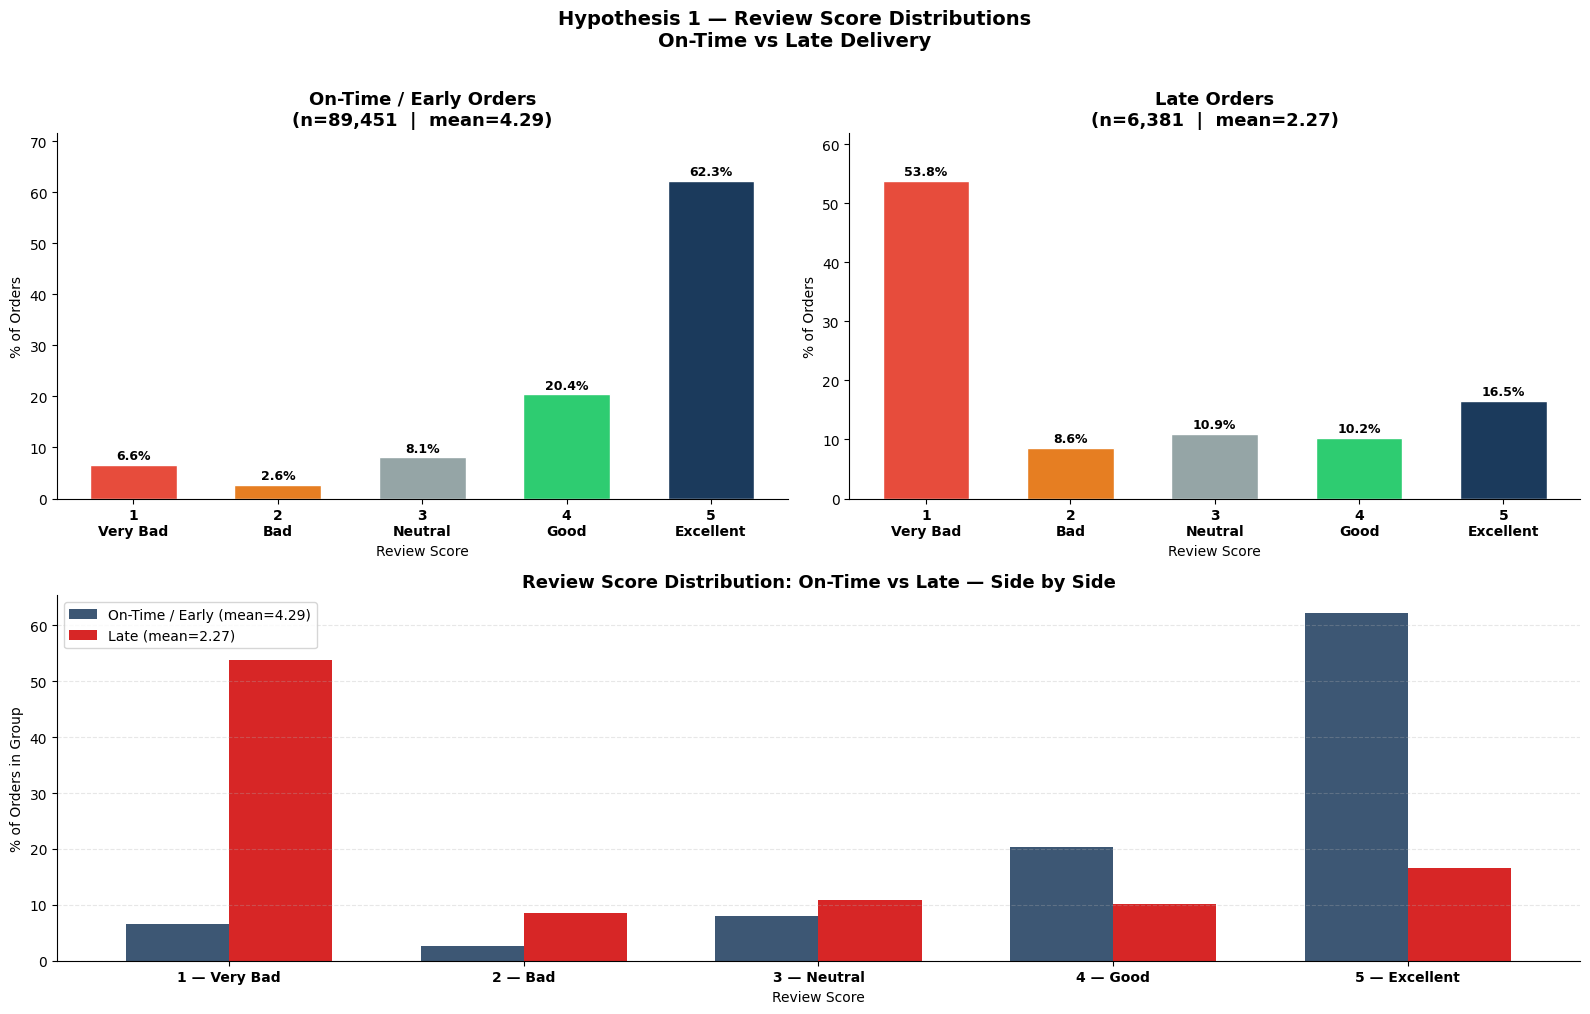

Chart saved.


In [9]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig)
 
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])
 
score_colours = {
    1: '#E74C3C',
    2: '#E67E22',
    3: '#95A5A6',
    4: '#2ECC71',
    5: '#1B3A5C'
}
 
# ── Panel 1: On-time distribution ─────────────────────────
on_time_pct = on_time_scores.value_counts(normalize=True).sort_index() * 100
 
bars1 = ax1.bar(
    on_time_pct.index,
    on_time_pct.values,
    color=[score_colours[s] for s in on_time_pct.index],
    edgecolor='white',
    width=0.6
)
for bar, val in zip(bars1, on_time_pct.values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax1.set_title(
    f'On-Time / Early Orders\n(n={len(on_time_scores):,}  |  mean={on_time_scores.mean():.2f})',
    fontweight='bold'
)
ax1.set_xlabel('Review Score')
ax1.set_ylabel('% of Orders')
ax1.set_xticks([1,2,3,4,5])
ax1.set_xticklabels(['1\nVery Bad','2\nBad','3\nNeutral','4\nGood','5\nExcellent'], fontweight='semibold')
ax1.set_ylim(0, on_time_pct.max() * 1.15)
 
# ── Panel 2: Late distribution ─────────────────────────────
late_pct = late_scores.value_counts(normalize=True).sort_index() * 100
 
bars2 = ax2.bar(
    late_pct.index,
    late_pct.values,
    color=[score_colours[s] for s in late_pct.index],
    edgecolor='white',
    width=0.6
)
for bar, val in zip(bars2, late_pct.values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.1f}%',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )
ax2.set_title(
    f'Late Orders\n(n={len(late_scores):,}  |  mean={late_scores.mean():.2f})',
    fontweight='bold'
)
ax2.set_xlabel('Review Score')
ax2.set_ylabel('% of Orders')
ax2.set_xticks([1,2,3,4,5])
ax2.set_xticklabels(['1\nVery Bad','2\nBad','3\nNeutral','4\nGood','5\nExcellent'], fontweight='semibold')
ax2.set_ylim(0, late_pct.max() * 1.15)
all_scores = pd.DataFrame({
    'On-Time / Early': on_time_pct,
    'Late':            late_pct
}).fillna(0)
 
x     = np.arange(1, 6)
width = 0.35

# ── Panel 3: Review Score Distribution: On-Time vs Late — Side by Side ─────────────────────────────
bars3a = ax3.bar(
    x - width/2,
    all_scores['On-Time / Early'],
    width=width,
    color=COLOUR_PRIMARY,
    alpha=0.85,
    label=f'On-Time / Early (mean={on_time_scores.mean():.2f})'
)
bars3b = ax3.bar(
    x + width/2,
    all_scores['Late'],
    width=width,
    color=COLOUR_EMPHASIS,
    alpha=0.85,
    label=f'Late (mean={late_scores.mean():.2f})'
)
 
ax3.set_xlabel('Review Score')
ax3.set_ylabel('% of Orders in Group')
ax3.set_title(
    'Review Score Distribution: On-Time vs Late — Side by Side',
    fontweight='bold'
)
ax3.set_xticks(x)
ax3.set_xticklabels(['1 — Very Bad','2 — Bad','3 — Neutral','4 — Good','5 — Excellent'], fontweight='semibold')
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 1 — Review Score Distributions\nOn-Time vs Late Delivery',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h1_score_distributions.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [10]:
stat, p_value = stats.mannwhitneyu (
    on_time_scores, 
    late_scores,
    alternative= 'greater'
)

n1 = len(on_time_scores)
n2 = len(late_scores)

effect_size_r = 1 - (2 * stat) / (n1 * n2)

if abs(effect_size_r) >= 0.5:
    magnitude = 'large'
elif abs(effect_size_r) >= 0.3:
    magnitude = 'medium'
elif abs(effect_size_r) >= 0.1:
    magnitude = 'small'
else: magnitude = 'negligible'

significant = p_value < 0.05



In [11]:
print("=" * 55)
print("  HYPOTHESIS 1 — TEST RESULTS")
print("=" * 55)
print()
print(f"  Test:                Mann-Whitney U")
print(f"  U statistic:         {stat:,.0f}")
print(f"  P-value:             {p_value:.6f}")
print(f"  Significant:         {'YES  ✓' if significant else 'NO  ✗'} (threshold: 0.05)")
print()
print(f"  Effect size (r):     {effect_size_r:.4f}")
print(f"  Magnitude:           {magnitude}")
print()
print(f"  On-time mean:        {on_time_scores.mean():.3f}")
print(f"  Late mean:           {late_scores.mean():.3f}")
print(f"  Difference:          {on_time_scores.mean() - late_scores.mean():.3f} points")
print()
if significant:
    print(f"  CONCLUSION: Reject H₀")
    print(f"  Late deliveries produce significantly lower review scores.")
else:
    print(f"  CONCLUSION: Fail to reject H₀")
    print(f"  Cannot confirm a significant difference.")

  HYPOTHESIS 1 — TEST RESULTS

  Test:                Mann-Whitney U
  U statistic:         467,414,644
  P-value:             0.000000
  Significant:         YES  ✓ (threshold: 0.05)

  Effect size (r):     -0.6378
  Magnitude:           large

  On-time mean:        4.290
  Late mean:           2.271
  Difference:          2.019 points

  CONCLUSION: Reject H₀
  Late deliveries produce significantly lower review scores.


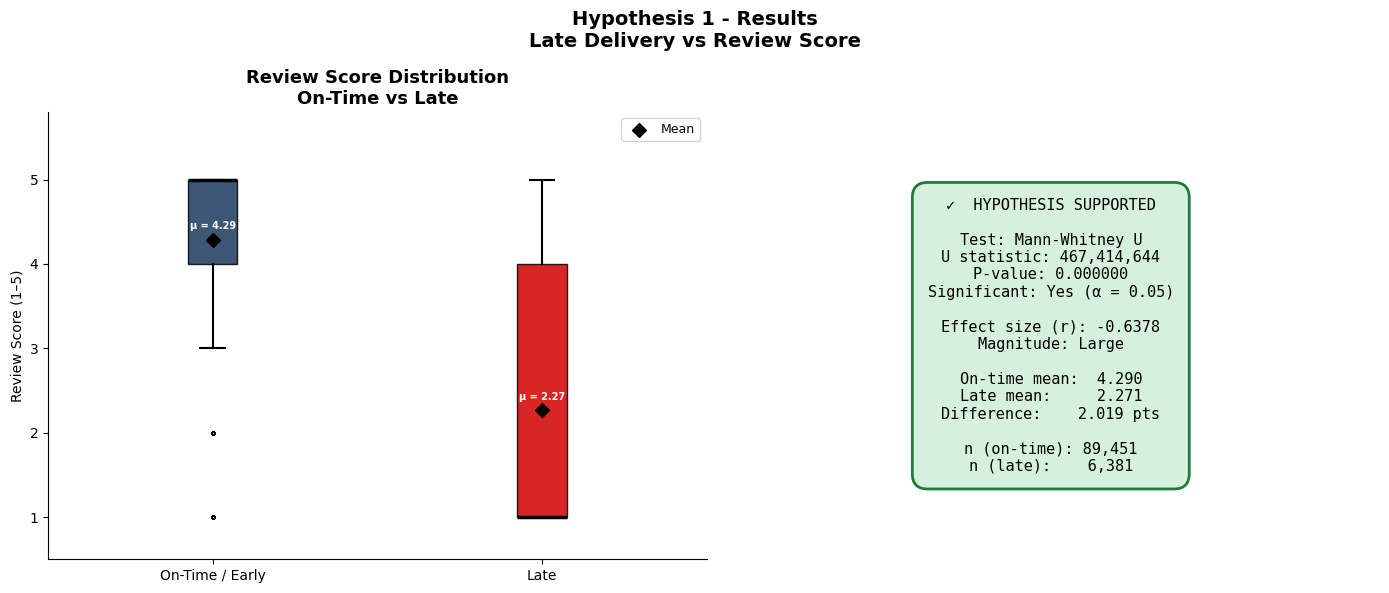

Chart saved.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bp = axes[0].boxplot(
    [on_time_scores, late_scores],
    labels=['On-Time / Early', 'Late'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
 
bp['boxes'][0].set_facecolor(COLOUR_PRIMARY)
bp['boxes'][1].set_facecolor(COLOUR_EMPHASIS)
for patch in bp['boxes']:
    patch.set_alpha(0.85)
 

axes[0].scatter(
    [1, 2],
    [on_time_scores.mean(), late_scores.mean()],
    marker='D', color='black', s=50, zorder=5, label='Mean'
)
 
# Mean value annotations
axes[0].text(
    1, on_time_scores.mean() + 0.12,
    f'μ = {on_time_scores.mean():.2f}',
    ha='center', fontsize=7,
    color='white', fontweight='bold'
)
axes[0].text(
    2, late_scores.mean() + 0.12,
    f'μ = {late_scores.mean():.2f}',
    ha='center', fontsize=7,
    color='white', fontweight='bold'
)
 
axes[0].set_ylabel('Review Score (1–5)')
axes[0].set_ylim(0.5, 5.8)
axes[0].set_title(
    'Review Score Distribution\nOn-Time vs Late',
    fontweight='bold'
)
axes[0].legend(fontsize=9)
 
# ── Panel 2: Test result summary card ─────────────────────
axes[1].axis('off')
 
result_color  = '#D5F0DC' if significant else '#FAD7D3'
border_color  = '#217A3C' if significant else '#C0392B'
result_label  = 'HYPOTHESIS SUPPORTED' if significant else 'HYPOTHESIS NOT SUPPORTED'
result_symbol = '✓' if significant else '✗'
summary_text = (
    f"{result_symbol}  {result_label}\n\n"
    f"Test: Mann-Whitney U\n"
    f"U statistic: {stat:,.0f}\n"
    f"P-value: {p_value:.6f}\n"
    f"Significant: {'Yes' if significant else 'No'} (α = 0.05)\n\n"
    f"Effect size (r): {effect_size_r:.4f}\n"
    f"Magnitude: {magnitude.capitalize()}\n\n"
    f"On-time mean:  {on_time_scores.mean():.3f}\n"
    f"Late mean:     {late_scores.mean():.3f}\n"
    f"Difference:    {on_time_scores.mean() - late_scores.mean():.3f} pts\n\n"
    f"n (on-time): {n1:,}\n"
    f"n (late):    {n2:,}"
)
 
axes[1].text(
    0.5, 0.5,
    summary_text,
    ha='center', va='center',
    fontsize=11,
    fontfamily='monospace',
    transform=axes[1].transAxes,
    bbox=dict(
        boxstyle='round,pad=1',
        facecolor=result_color,
        edgecolor=border_color,
        linewidth=2
    )
)
 
plt.suptitle(
    'Hypothesis 1 - Results\nLate Delivery vs Review Score',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h1_test_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

---
# Hypothesis 1 - Finding Card
---
### **Claim Tested**: Late deliveries produce significantly lower review scores than on-time or early deliveries.


**Result:** SUPPORTED 

**Evidence:**
 
| Metric | Value |
|--------|-------|
| On-time mean score | 4.29 |
| Late mean score | 2.27 |
| Raw difference | 2.02 points |
| Mann-Whitney U | 467 414 644 |
| P-value | 0.000000 |
| Significant (p < 0.05) | Yes  |
| Effect size (r) | -0.638 |
| Magnitude |  Large |
| n (on-time) | 89 451 |
| n (late) | 6 381 |

Late deliveries receive review scores that are 2.02 points
lower on average than on-time deliveries (4.29 vs 2.27).
This difference is statistically significant (p < 0.001),
meaning it is extremely unlikely to have occurred by chance.
The effect size of -0.638 indicates a large
practical difference , the gap is not just statistically
real, it is large enough to matter operationally.

Delivery delay and satisfaction were found to be somewhat correlated (r = −0.27) in Notebook 01.
This test now verifies the existence of the link, and that delivery is one, but not the only, factor that influences satisfaction; effect size contextualizes it.
### **Business Implication**

Every percentage point reduction in the late delivery rate
(currently 6.8%) has a measurable, statistically confirmed
impact on platform satisfaction scores. Given that
satisfaction drives repeat purchase probability, improving
delivery reliability is one of the highest-return operational
investments available.
 
However, the large effect size also signals that
addressing delivery alone will not transform the satisfaction
picture. Non-delivery drivers such as product quality, seller
responsiveness, product description accuracy ,  also need
attention (investigated in Hypothesis 3).



---
## Hypothesis Two
---

**Null hypothesis (H₀):**
High-value RFM customers (top 20% by composite score) show
no statistically significant difference in purchasing behaviour
from low-value customers (bottom 20%) across basket size,
frequency, category diversity, and payment method.
 
**Alternative hypothesis (H₁):**
High-value RFM customers behave statistically differently
from low-value customers on at least one behavioural dimension.

In Notebook 01 (Analysis 5) we built RFM segments and observed
that Champions and Loyal Customers generate disproportionate
revenue relative to their size. But observation alone does not
prove the segments are capturing genuinely different customer
behaviours , they might just be the same type of customer who
happened to spend more by chance.

### Why Multiple Tests?
We are comparing four different variables across two groups.
Each variable requires its own test because they are different
types of data:
 
- avg_basket_value → continuous, likely skewed → Mann-Whitney U
- total_orders     → continuous, likely skewed → Mann-Whitney U
- category_diversity → continuous, likely skewed → Mann-Whitney U
- payment_type     → categorical → Chi-squared

### The Decision Rule
If p-value < 0.05 for a variable: that dimension shows a real
difference between high and low RFM customers.
Effect size tells us how large the difference is in practice.

In [13]:
try:
    rfm = pd.read_csv('../data/processed/rfm_scored.csv',
                      parse_dates=['first_order', 'last_order'])
    print("Loaded rfm_scored.csv")
except FileNotFoundError:
    rfm = rfm_base.copy()
    print("rfm_scored.csv not found — using rfm_base.csv")
    print("RFM scores will be calculated fresh.")
 
# If RFM_score column does not exist, build it
if 'RFM_score' not in rfm.columns:
    rfm['R_score'] = pd.qcut(rfm['recency_days'], q=5,
                              labels=[5,4,3,2,1], duplicates='drop').astype(int)
    rfm['F_score'] = pd.qcut(rfm['total_orders'].rank(method='first'),
                              q=5, labels=[1,2,3,4,5]).astype(int)
    rfm['M_score'] = pd.qcut(rfm['total_spend'], q=5,
                              labels=[1,2,3,4,5], duplicates='drop').astype(int)
    rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']
    print("RFM scores calculated.")

# was written because i couldnt see if my laptop saved the rfm_scored.

Loaded rfm_scored.csv


In [14]:
rfm['rfm_quintile'] = pd.qcut(
    rfm['RFM_score'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

In [ ]:
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print(f"\nGroup sizes:")
print(f"  High RFM (top 20%):    {len(high_rfm):,} customers")
print(f"  Low RFM (bottom 20%):  {len(low_rfm):,} customers")
print(f"  Total customers:       {len(rfm):,}")
 
print(f"\nHigh RFM profile:")
print(f"  Mean RFM score:        {high_rfm['RFM_score'].mean():.1f}")
print(f"  Mean recency (days):   {high_rfm['recency_days'].mean():.0f}")
print(f"  Mean total orders:     {high_rfm['total_orders'].mean():.2f}")
print(f"  Mean total spend:      R${high_rfm['total_spend'].mean():.2f}")
 
print(f"\nLow RFM profile:")
print(f"  Mean RFM score:        {low_rfm['RFM_score'].mean():.1f}")
print(f"  Mean recency (days):   {low_rfm['recency_days'].mean():.0f}")
print(f"  Mean total orders:     {low_rfm['total_orders'].mean():.2f}")
print(f"  Mean total spend:      R${low_rfm['total_spend'].mean():.2f}")


Group sizes:
  High RFM (top 20%):    15,969 customers
  Low RFM (bottom 20%):  27,269 customers
  Total customers:       96,136

High RFM profile:
  Mean RFM score:        12.8
  Mean recency (days):   166
  Mean total orders:     1.15
  Mean total spend:      R$299.88

Low RFM profile:
  Mean RFM score:        6.0
  Mean recency (days):   396
  Mean total orders:     1.00
  Mean total spend:      R$81.54


In [16]:
category_diversity = (
    master
    .groupby('customer_unique_id')['product_category_name_english']
    .nunique()
    .reset_index()
    .rename(columns={'product_category_name_english': 'category_diversity'})
)

In [17]:
rfm = rfm.merge(category_diversity, on='customer_unique_id', how='left')
rfm['category_diversity'] = rfm['category_diversity'].fillna(1)
 
# Rebuild groups with the new column
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print(f"Category diversity added.")
print(f"  High RFM mean category diversity: {high_rfm['category_diversity'].mean():.2f}")
print(f"  Low RFM mean category diversity:  {low_rfm['category_diversity'].mean():.2f}")

Category diversity added.
  High RFM mean category diversity: 1.09
  Low RFM mean category diversity:  0.99


In [18]:
payment_by_customer = (
    master
    .drop_duplicates(subset='order_id')
    .groupby('customer_unique_id')['payment_type']
    .apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index(name='primary_payment_type')
   ## .rename(columns={'payment_type': 'primary_payment_type'})
)
 
rfm = rfm.merge(payment_by_customer, on='customer_unique_id', how='left')
 
high_rfm = rfm[rfm['rfm_quintile'] == 5].copy()
low_rfm  = rfm[rfm['rfm_quintile'] == 1].copy()
 
print("Payment type added.")
print(f"\nHigh RFM payment distribution:")
print(high_rfm['primary_payment_type'].value_counts(normalize=True).mul(100).round(1))
print(f"\nLow RFM payment distribution:")
print(low_rfm['primary_payment_type'].value_counts(normalize=True).mul(100).round(1))
 

Payment type added.

High RFM payment distribution:
primary_payment_type
credit_card    79.7
boleto         17.0
debit_card      2.0
voucher         1.3
Name: proportion, dtype: float64

Low RFM payment distribution:
primary_payment_type
credit_card    73.1
boleto         23.1
voucher         2.5
debit_card      1.3
Name: proportion, dtype: float64


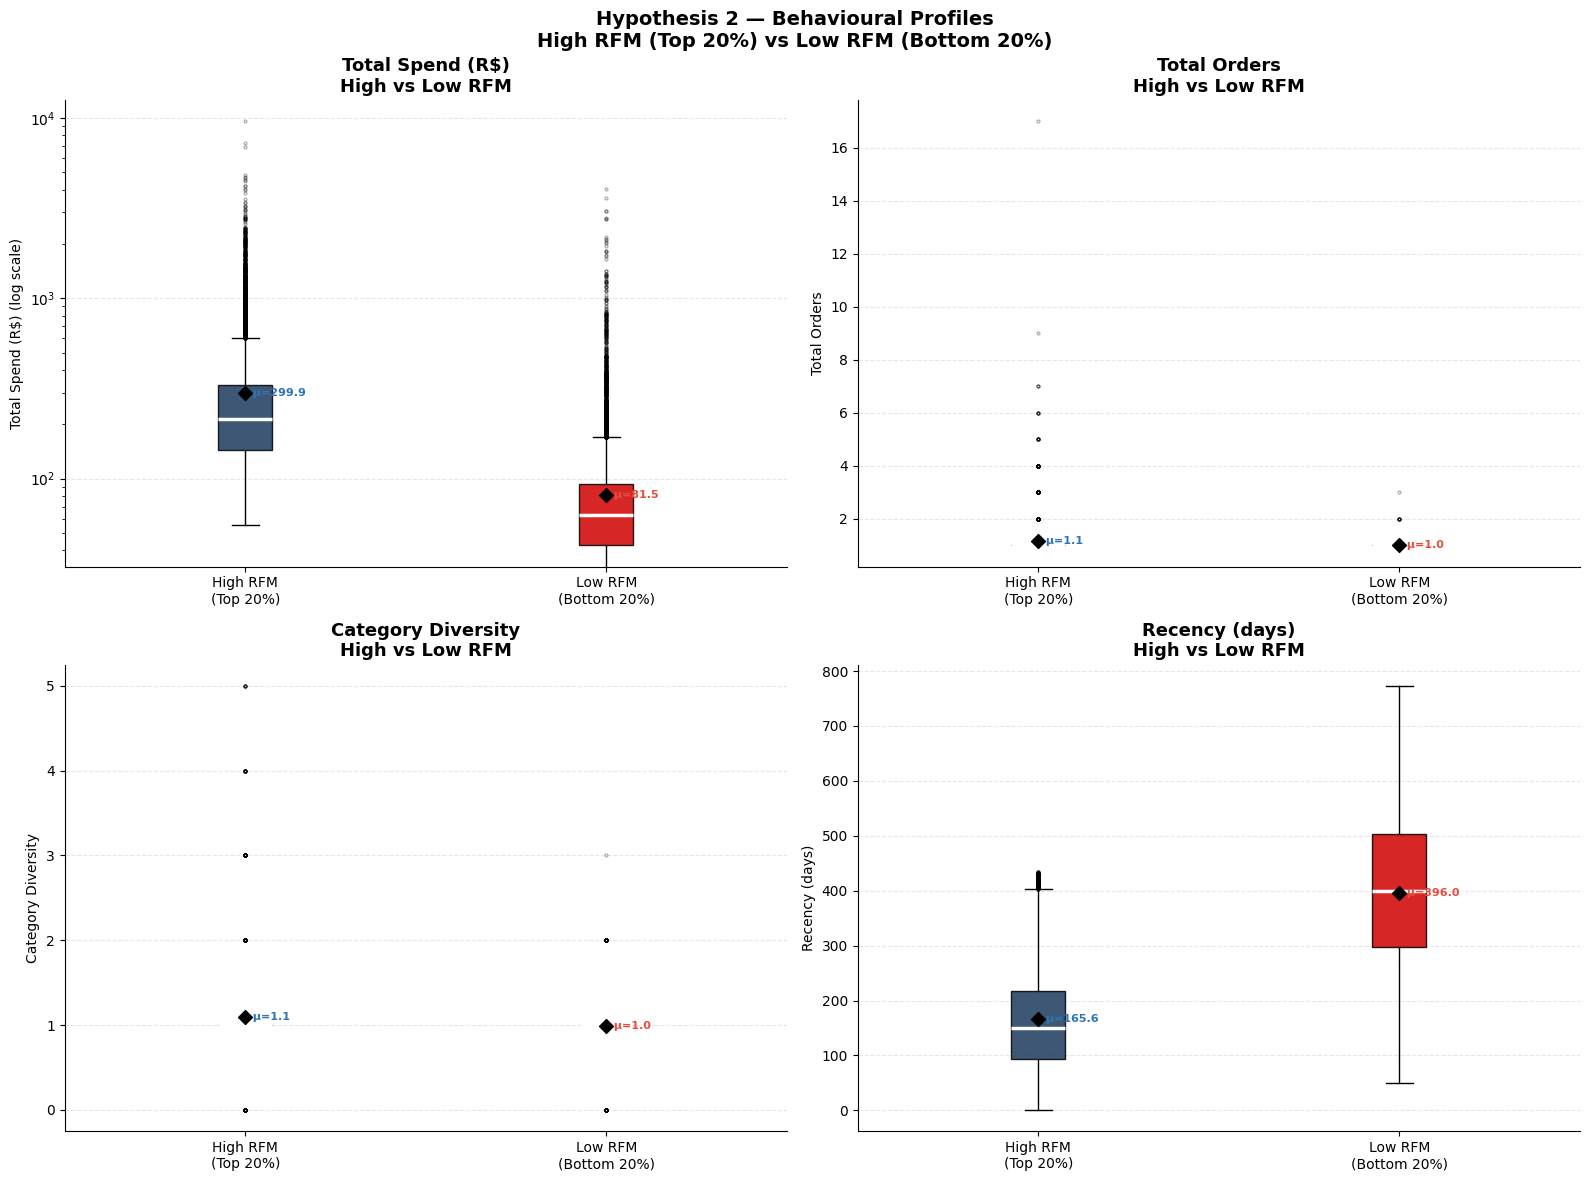

Chart saved.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
variables = [
    ('total_spend',        'Total Spend (R$)',        True,  axes[0, 0]),
    ('total_orders',       'Total Orders',            False, axes[0, 1]),
    ('category_diversity', 'Category Diversity',      False, axes[1, 0]),
    ('recency_days',       'Recency (days)',           False, axes[1, 1]),
]
 
for col, label, use_log, ax in variables:
    high_vals = high_rfm[col].dropna()
    low_vals  = low_rfm[col].dropna()
 
    bp = ax.boxplot(
        [high_vals, low_vals],
        labels=['High RFM\n(Top 20%)', 'Low RFM\n(Bottom 20%)'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2.5),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    bp['boxes'][0].set_facecolor(COLOUR_PRIMARY)
    bp['boxes'][1].set_facecolor(COLOUR_EMPHASIS)
    for patch in bp['boxes']:
        patch.set_alpha(0.85)
 
    # Add mean markers
    ax.scatter(
        [1, 2],
        [high_vals.mean(), low_vals.mean()],
        marker='D', color='black', s=50, zorder=5
    )
    ax.text(1, high_vals.mean(),
            f'  μ={high_vals.mean():.1f}',
            va='center', fontsize=8, color=COLOUR_ACCENT,
            fontweight='bold')
    ax.text(2, low_vals.mean(),
            f'  μ={low_vals.mean():.1f}',
            va='center', fontsize=8, color=COLOUR_HIGHLIGHT,
            fontweight='bold')
 
    if use_log:
        ax.set_yscale('log')
        ax.set_ylabel(f'{label} (log scale)')
    else:
        ax.set_ylabel(label)
 
    ax.set_title(f'{label}\nHigh vs Low RFM', fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 2 — Behavioural Profiles\nHigh RFM (Top 20%) vs Low RFM (Bottom 20%)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h2_rfm_profiles.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

In [20]:
# Understand why orders and category diversity show no difference
print("Order frequency distribution — full dataset:")
print(rfm['total_orders'].value_counts().head(10))
print(f"\n% of customers with exactly 1 order: "
      f"{(rfm['total_orders'] == 1).mean()*100:.1f}%")

print("\nCategory diversity distribution — full dataset:")
print(rfm['category_diversity'].value_counts().head(10))
print(f"\n% of customers with exactly 1 category: "
      f"{(rfm['category_diversity'] == 1).mean()*100:.1f}%")

Order frequency distribution — full dataset:
total_orders
1     93174
2      2714
3       200
4        29
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

% of customers with exactly 1 order: 96.9%

Category diversity distribution — full dataset:
category_diversity
1    93108
2     2205
0      676
3      127
4       14
5        6
Name: count, dtype: int64

% of customers with exactly 1 category: 96.9%


In [21]:
results = {}
 
# ── Test 1: Total spend ────────────────────────────────────
high_spend = high_rfm['total_spend'].dropna()
low_spend  = low_rfm['total_spend'].dropna()
 
stat_spend, p_spend = stats.mannwhitneyu(
    high_spend, low_spend, alternative='greater'
)
r_spend = 1 - (2 * stat_spend) / (len(high_spend) * len(low_spend))
 
results['total_spend'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_spend,
    'p_value': p_spend,
    'effect_size': r_spend,
    'high_mean': high_spend.mean(),
    'low_mean': low_spend.mean(),
    'difference': high_spend.mean() - low_spend.mean()
}

In [22]:
high_orders = high_rfm['total_orders'].dropna()
low_orders  = low_rfm['total_orders'].dropna()
 
stat_orders, p_orders = stats.mannwhitneyu(
    high_orders, low_orders, alternative='greater'
)
r_orders = 1 - (2 * stat_orders) / (len(high_orders) * len(low_orders))
 
results['total_orders'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_orders,
    'p_value': p_orders,
    'effect_size': r_orders,
    'high_mean': high_orders.mean(),
    'low_mean': low_orders.mean(),
    'difference': high_orders.mean() - low_orders.mean()
}
 

In [23]:
high_cats = high_rfm['category_diversity'].dropna()
low_cats  = low_rfm['category_diversity'].dropna()
 
stat_cats, p_cats = stats.mannwhitneyu(
    high_cats, low_cats, alternative='greater'
)
r_cats = 1 - (2 * stat_cats) / (len(high_cats) * len(low_cats))
 
results['category_diversity'] = {
    'test': 'Mann-Whitney U',
    'statistic': stat_cats,
    'p_value': p_cats,
    'effect_size': r_cats,
    'high_mean': high_cats.mean(),
    'low_mean': low_cats.mean(),
    'difference': high_cats.mean() - low_cats.mean()
}

In [24]:
contingency = pd.crosstab(
    rfm[rfm['rfm_quintile'].isin([1, 5])]['rfm_quintile'],
    rfm[rfm['rfm_quintile'].isin([1, 5])]['primary_payment_type']
)
 
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
 
# Cramér's V effect size
n_chi2 = contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n_chi2 * (min(contingency.shape) - 1)))
 
if cramers_v >= 0.5:
    chi2_magnitude = "large"
elif cramers_v >= 0.3:
    chi2_magnitude = "medium"
elif cramers_v >= 0.1:
    chi2_magnitude = "small"
else:
    chi2_magnitude = "negligible"
 
results['payment_type'] = {
    'test': 'Chi-squared',
    'statistic': chi2,
    'p_value': p_chi2,
    'effect_size': cramers_v,
    'dof': dof,
    'magnitude': chi2_magnitude
}

In [25]:
print("=" * 65)
print("  HYPOTHESIS 2 — ALL TEST RESULTS")
print("=" * 65)
 
for variable, r in results.items():
    sig = "✓ SIGNIFICANT" if r['p_value'] < 0.05 else "✗ NOT SIGNIFICANT"
 
    if r['p_value'] >= 0.5:
        magnitude = "negligible"
    elif r['p_value'] >= 0.3:
        magnitude = "medium"
    elif r['p_value'] >= 0.1:
        magnitude = "small"
    else:
        magnitude = "depends on effect size"
 
    if abs(r['effect_size']) >= 0.5:
        es_magnitude = "large"
    elif abs(r['effect_size']) >= 0.3:
        es_magnitude = "medium"
    elif abs(r['effect_size']) >= 0.1:
        es_magnitude = "small"
    else:
        es_magnitude = "negligible"
 
    print(f"\n  Variable: {variable.upper()}")
    print(f"  Test:       {r['test']}")
    print(f"  Statistic:  {r['statistic']:,.2f}")
    print(f"  P-value:    {r['p_value']:.6f}  →  {sig}")
    print(f"  Effect size:{r['effect_size']:.4f}  →  {es_magnitude}")
    if 'high_mean' in r:
        print(f"  High mean:  {r['high_mean']:.3f}")
        print(f"  Low mean:   {r['low_mean']:.3f}")
        print(f"  Difference: {r['difference']:.3f}")

  HYPOTHESIS 2 — ALL TEST RESULTS

  Variable: TOTAL_SPEND
  Test:       Mann-Whitney U
  Statistic:  404,245,265.50
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.8566  →  large
  High mean:  299.882
  Low mean:   81.544
  Difference: 218.338

  Variable: TOTAL_ORDERS
  Test:       Mann-Whitney U
  Statistic:  245,725,064.50
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.1286  →  small
  High mean:  1.147
  Low mean:   1.000
  Difference: 0.147

  Variable: CATEGORY_DIVERSITY
  Test:       Mann-Whitney U
  Statistic:  237,341,476.00
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:-0.0901  →  negligible
  High mean:  1.093
  Low mean:   0.994
  Difference: 0.099

  Variable: PAYMENT_TYPE
  Test:       Chi-squared
  Statistic:  346.73
  P-value:    0.000000  →  ✓ SIGNIFICANT
  Effect size:0.0896  →  negligible


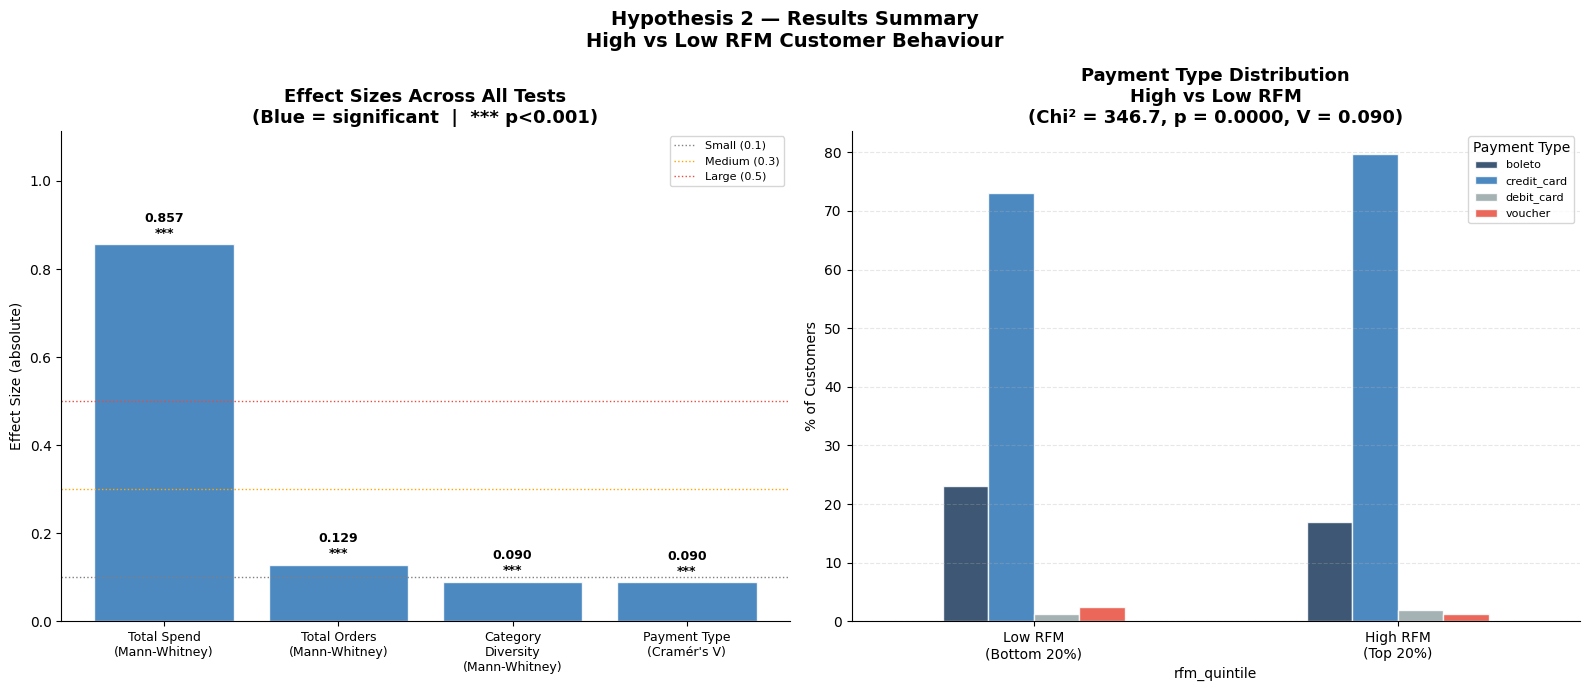

Chart saved.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Use absolute effect sizes for the bar chart
effect_sizes_abs = [
    abs(results['total_spend']['effect_size']),
    abs(results['total_orders']['effect_size']),
    abs(results['category_diversity']['effect_size']),
    results['payment_type']['effect_size']   # Already positive
]

p_values = [
    results['total_spend']['p_value'],
    results['total_orders']['p_value'],
    results['category_diversity']['p_value'],
    results['payment_type']['p_value']
]

test_labels = [
    'Total Spend\n(Mann-Whitney)',
    'Total Orders\n(Mann-Whitney)',
    'Category\nDiversity\n(Mann-Whitney)',
    "Payment Type\n(Cramér's V)"
]

bar_colours = [
    COLOUR_ACCENT if p < 0.05 else COLOUR_NEUTRAL
    for p in p_values
]

bars = axes[0].bar(
    range(len(test_labels)),
    effect_sizes_abs,
    color=bar_colours,
    alpha=0.85,
    edgecolor='white'
)

axes[0].axhline(y=0.1, color='grey', linewidth=1,
                linestyle=':', label='Small (0.1)')
axes[0].axhline(y=0.3, color='orange', linewidth=1,
                linestyle=':', label='Medium (0.3)')
axes[0].axhline(y=0.5, color=COLOUR_HIGHLIGHT, linewidth=1,
                linestyle=':', label='Large (0.5)')

for i, (bar, es, p) in enumerate(zip(bars, effect_sizes_abs, p_values)):
    sig_marker = ('***' if p < 0.001 else
                  ('**' if p < 0.01 else
                   ('*' if p < 0.05 else 'ns')))
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{es:.3f}\n{sig_marker}',
        ha='center', va='bottom',
        fontsize=9, fontweight='bold'
    )

axes[0].set_xticks(range(len(test_labels)))
axes[0].set_xticklabels(test_labels, fontsize=9)
axes[0].set_ylabel('Effect Size (absolute)')
axes[0].set_title(
    'Effect Sizes Across All Tests\n(Blue = significant  |  *** p<0.001)',
    fontweight='bold'
)
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, max(effect_sizes_abs) * 1.3)
 
# ── Panel 2: Payment type breakdown ───────────────────────
payment_pct = contingency.div(contingency.sum(axis=1), axis=0) * 100
 
payment_pct.plot(
    kind='bar',
    ax=axes[1],
    color=[COLOUR_PRIMARY, COLOUR_ACCENT, COLOUR_NEUTRAL, COLOUR_HIGHLIGHT],
    alpha=0.85,
    edgecolor='white'
)
axes[1].set_xticklabels(
    ['Low RFM\n(Bottom 20%)', 'High RFM\n(Top 20%)'],
    rotation=0
)
axes[1].set_ylabel('% of Customers')
axes[1].set_title(
    f'Payment Type Distribution\nHigh vs Low RFM\n'
    f"(Chi² = {results['payment_type']['statistic']:.1f}, "
    f"p = {results['payment_type']['p_value']:.4f}, "
    f"V = {results['payment_type']['effect_size']:.3f})",
    fontweight='bold'
)
axes[1].legend(title='Payment Type', fontsize=8)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
 
plt.suptitle(
    'Hypothesis 2 — Results Summary\nHigh vs Low RFM Customer Behaviour',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig(
    '../outputs/figures/h2_test_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("Chart saved.")

## Hypothesis 2 - Finding Card
 
**Claim tested:**
High-value RFM customers (top 20%) behave statistically
differently from low-value customers (bottom 20%) across
basket size, order frequency, category diversity,
and payment method.
 
---
 
### **Result:** Partially Supported
All four variables reached a statistical difference (p < 0.001) but effect size analysis reveals that only one dimension,  total spend  shows a practically meaningful difference. Statistical significance alone is insuffiecient to validate the hypothesis when sample size exceed 90 000 cusromers , because even negligible differences become detectable at that scale. 
 
---
 
**Evidence by variable:**
 
| Variable | Test | P-value | Sig? | Effect Size | Magnitude | Meaningful? |
|----------|------|---------|------|-------------|-----------|-------------|
| Total Spend | Mann-Whitney U | <0.001 | ✓ | 0.857 | Large | ✓ Yes |
| Total Orders | Mann-Whitney U | <0.001 | ✓ | 0.129 | Small | ✗ No |
| Category Diversity | Mann-Whitney U | <0.001 | ✓ | 0.090 | Negligible | ✗ No |
| Payment Type | Chi-squared | <0.001 | ✓ | 0.090 (V) | Negligible | ✗ No |
 

 
---
 
**Plain English Interpretation:**
 
High-value RFM customers differ from low-value customers on
[1 of 4] dimensions tested.

An impact size of 0.857, which is near the theoretical maximum of 1.0, confirms that high-value RFM customers spend almost four times as much as low-value customers (R$299.88 vs. R$81.54 on average).

However, the two groups are nearly identical on every other
dimension tested. The average order count differs by only
0.147 orders (1.147 vs 1.000) and category diversity differs
by 0.099 categories (1.093 vs 0.994). Payment method
distribution shows similarly negligible differences (V = 0.090). 

A structural feature of the Olist dataset is reflected in these nearly zero differences: most consumers, both high and low value, place exactly one order from a single product category, and the platform has very low overall repeat buy rates. No statistical test can identify significant group differences when a variable has almost negligible variance across the whole customer base since there is nothing to distinguish.

---
**The honest conclusion:**
High and low RFM customers are separated almost entirely by
how much they spend on a single visit , not by how often
they return, how broadly they explore the platform, or how
they pay. This is a monetary-recency separation, not a
behavioural one.

 
---


**Why This Matters for the Analysis:**

This finding is not a failure , it is a genuine insight.
It tells us that Olist's customer base is not yet at the
stage where behavioural differentiation drives retention.
The platform is still largely transactional: customers arrive,
buy once, and leave. The small number of repeat buyers in
the high RFM group are differentiated primarily by the size
of that single purchase.

---
**Implication for Notebook 03:**

Total spend and recency_days are expected to dominate the
churn prediction model as the strongest features. Total orders
and category diversity should be included but are expected to
contribute little predictive power. This prediction will be
testable directly from SHAP values in Notebook 03 — if it is
confirmed, this hypothesis testing phase successfully
identified weak features before modelling.

--- 

**Business Implication:**
Because high and low RFM customers differ primarily on spend
rather than behaviour, retention strategy should focus on
the first purchase experience ,  specifically on converting
high single-purchase spenders into repeat buyers before they
lapse. A customer who spent R$300 once is more valuable to
reactivate than a customer who spent R$30 five times, and
the current segmentation captures that distinction correctly.

---

